<a href="https://colab.research.google.com/github/maiaramai319-art/Amostragem/blob/main/teste_de_hipotese.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Na pesquisa científica, conclusões não podem ser baseadas em "impressões visuais" de um gráfico. Se a resistência média de um cimento curado a $55^\circ\text{C}$ foi de $4,5\text{ MPa}$ e a do curado a $20^\circ\text{C}$ foi de $3,8\text{ MPa}$, precisamos provar que esses $0,7\text{ MPa}$ de diferença são fruto de uma alteração química real (ativação térmica) e não de meras variações aleatórias do laboratório (como pequenas falhas na moldagem ou imprecisão da prensa).

O Teste de Hipóteses é o método estatístico que nos permite tomar essa decisão com rigor matemático. Ele funciona confrontando duas afirmações mutuamente exclusivas:

1. A Hipótese Nula ($H_0$)É a hipótese da igualdade ou do ceticismo. Ela assume que os fatores que você está manipulando não causam nenhum efeito real.Para o teor de argila: $H_0$ afirma que substituir o cimento por argila calcinada não altera a resistência à tração.

Para a temperatura: $H_0$ afirma que curar o cimento belítico em temperaturas mais altas não modifica a velocidade de hidratação ou a resistência.Para a interação: $H_0$ afirma que o efeito da argila independe da temperatura de cura.

2. A Hipótese Alternativa ($H_1$ ou $H_a$)É a hipótese do pesquisador, aquilo que você tenta provar na sua dissertação. Ela afirma que existe um efeito significativo.Para o seu projeto: $H_1$ afirma que a combinação de argila calcinada com o aumento controlado da temperatura de cura altera de forma estatisticamente significativa as propriedades mecânicas e microestruturais do aglomerante belítico.

Como Tomamos a Decisão? (O critério do p-value)Ao rodar a ANOVA no Python, o algoritmo calcula uma probabilidade conhecida como valor-p (p-value).Fixando o nível de significância padrão da área tecnológica em 5% ($\alpha = 0,05$), estabelecemos a seguinte regra de corte:

Se $\text{valor-p} < 0,05$: A probabilidade de obter essa diferença por mero acaso é menor que 5%. Portanto, rejeitamos a Hipótese Nula ($H_0$) e aceitamos a Hipótese Alternativa ($H_1$). O efeito é considerado estatisticamente significativo.Se $\text{valor-p} \ge 0,05$: A diferença encontrada pode ser apenas ruído experimental. Portanto, não podemos rejeitar $H_0$. Os grupos são considerados estatisticamente equivalentes (empate técnico).



          DADOS DOS CORPOS DE PROVA (RESISTÊNCIA À TRAÇÃO - MPa)
   Cura_20C_MPa  Cura_55C_MPa
0          2.27          4.68
1          2.18          4.54
2          2.30          4.32
3          2.43          4.50
4          2.16          4.32
5          2.16          4.32

                RESULTADO DO TESTE DE HIPÓTESES (TESTE t)
Média do Grupo 20°C: 2.25 MPa
Média do Grupo 55°C: 4.44 MPa
Valor-t calculado:   -28.9060
Valor-p (p-value):   0.000000
-----------------------------------------------------------------
VEREDITO: REJEITA-SE A HIPÓTESE NULA (H0).
Conclusão: Há uma diferença estatisticamente significativa entre as mídias.
A ativação térmica a 55°C realmente alterou a resistência à tração.



/tmp/ipykernel_935/3378910936.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Temperatura', y='Tracao_MPa', data=df_long, capsize=0.1, errorbar='sd', palette='Blues_d')


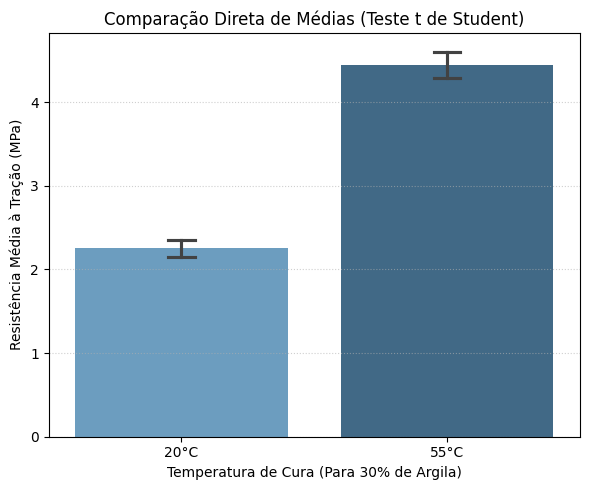

In [7]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. SIMULAÇÃO DOS DADOS DO LABORATÓRIO (Amostras Independentes)
# ==============================================================================
np.random.seed(42)
n_amostras = 6  # Número de corpos de prova ensaiados por grupo

# Grupo A: 30% de argila calcinada curada a 20°C (Cura Padrão)
grupo_A_20C = np.random.normal(loc=2.20, scale=0.15, size=n_amostras)

# Grupo B: 30% de argila calcinada curada a 55°C (Ativação Térmica)
grupo_B_55C = np.random.normal(loc=4.40, scale=0.18, size=n_amostras)

# Organizando em um DataFrame para facilitar a visualização
df_teste_t = pd.DataFrame({
    'Cura_20C_MPa': np.round(grupo_A_20C, 2),
    'Cura_55C_MPa': np.round(grupo_B_55C, 2)
})

print("="*65)
print("          DADOS DOS CORPOS DE PROVA (RESISTÊNCIA À TRAÇÃO - MPa)")
print("="*65)
print(df_teste_t)
print("="*65 + "\n")

# ==============================================================================
# 2. EXECUÇÃO DO TESTE T DE STUDENT (SEM ANOVA)
# ==============================================================================
# Executa o teste t para duas amostras independentes
t_estatistica, p_valor = stats.ttest_ind(grupo_A_20C, grupo_B_55C, equal_var=True)

# Média de cada grupo
media_A = np.mean(grupo_A_20C)
media_B = np.mean(grupo_B_55C)

# ==============================================================================
# 3. VEREDITO DO TESTE DE HIPÓTESES (alpha = 0.05)
# ==============================================================================
print("="*65)
print("                RESULTADO DO TESTE DE HIPÓTESES (TESTE t)")
print("="*65)
print(f"Média do Grupo 20°C: {media_A:.2f} MPa")
print(f"Média do Grupo 55°C: {media_B:.2f} MPa")
print(f"Valor-t calculado:   {t_estatistica:.4f}")
print(f"Valor-p (p-value):   {p_valor:.6f}")
print("-"*65)

if p_valor < 0.05:
    print("VEREDITO: REJEITA-SE A HIPÓTESE NULA (H0).")
    print("Conclusão: Há uma diferença estatisticamente significativa entre as mídias.")
    print("A ativação térmica a 55°C realmente alterou a resistência à tração.")
else:
    print("VEREDITO: NÃO SE REJEITA A HIPÓTESE NULA (H0).")
    print("Conclusão: A diferença observada pode ser mero erro aleatório do laboratório.")
    print("As temperaturas de cura geraram resultados estatisticamente equivalentes.")
print("="*65 + "\n")

# ==============================================================================
# 4. GERAR GRÁFICO COMPARATIVO DIRETO
# ==============================================================================
# Remodelando os dados apenas para o gráfico
df_long = pd.DataFrame({
    'Temperatura': ['20°C']*n_amostras + ['55°C']*n_amostras,
    'Tracao_MPa': np.concatenate([grupo_A_20C, grupo_B_55C])
})

plt.figure(figsize=(6, 5))
sns.barplot(x='Temperatura', y='Tracao_MPa', data=df_long, capsize=0.1, errorbar='sd', palette='Blues_d')
plt.title('Comparação Direta de Médias (Teste t de Student)')
plt.xlabel('Temperatura de Cura (Para 30% de Argila)')
plt.ylabel('Resistência Média à Tração (MPa)')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()